# Dataset, DataLoader & Image Classification — Fashion-MNIST

Learn how to use PyTorch's `Dataset` and `DataLoader` APIs, apply **data augmentation**, and train a CNN on **Fashion-MNIST** (60,000 clothing images, 10 classes).

In [1]:
import torch, random
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Dataset vs DataLoader
- **Dataset**: stores data, returns one sample at a time via `__getitem__(idx)`
- **DataLoader**: wraps a Dataset, creates shuffled **mini-batches** for training

## 2. Data Augmentation — Training Transforms Only

In [2]:
# Training: apply random augmentations to help the model generalize
train_transform = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

# Test: NO augmentation (we need real, unmodified test data)
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

print("Transforms defined!")

Transforms defined!


## 3. Load Fashion-MNIST Dataset

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

train_ds = FashionMNIST(root="./data", train=True,  download=True, transform=train_transform)
test_ds  = FashionMNIST(root="./data", train=False, download=True, transform=test_transform)

print("Train size:", len(train_ds))
print("Test size :", len(test_ds))
print("Image shape (one sample):", train_ds[0][0].shape)  # (1, 28, 28)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]


Train size: 60000
Test size : 10000
Image shape (one sample): torch.Size([1, 28, 28])


## 4. Visualize Augmented Training Samples

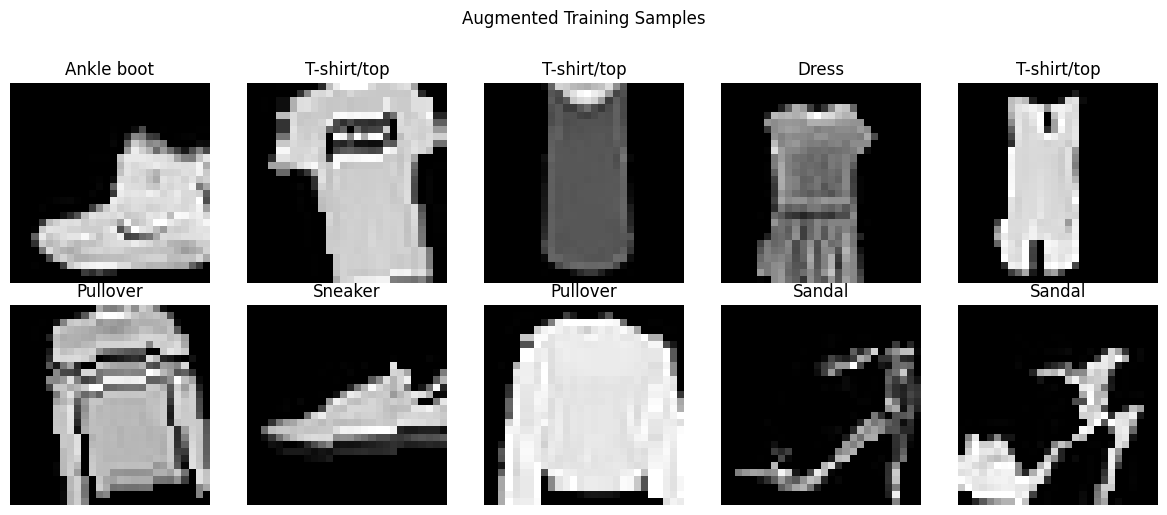

In [4]:
def unnormalize(img_tensor, mean=0.2860, std=0.3530):
    return img_tensor * std + mean

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    img, label = train_ds[i]
    img_disp = unnormalize(img).squeeze(0)
    axes[i].imshow(img_disp, cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")
plt.suptitle("Augmented Training Samples", y=1.02)
plt.tight_layout(); plt.show()

## 5. Create DataLoaders

In [5]:
train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True
)
test_loader = DataLoader(
    test_ds, batch_size=256, shuffle=False,
    num_workers=2, pin_memory=True
)

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)   # (64, 1, 28, 28)
print("Batch y shape:", yb.shape)   # (64,)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch X shape: torch.Size([64, 1, 28, 28])
Batch y shape: torch.Size([64])


## 6. Define a Simple CNN

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Feature extraction with convolutions
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (B,16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # (B,16,14,14)
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # (B,32,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2)                              # (B,32,7,7)
        )
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),          # regularization: randomly zero 30% of neurons
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 206,922


## 7. Loss, Optimizer & Training

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)
    return total_loss / total, correct / total

In [8]:
epochs = 5
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
          f"Test Loss: {te_loss:.4f}, Acc: {te_acc:.4f}")

Epoch 01 | Train Loss: 0.7140, Acc: 0.7302 | Test Loss: 0.4668, Acc: 0.8267
Epoch 02 | Train Loss: 0.5295, Acc: 0.8005 | Test Loss: 0.3903, Acc: 0.8531
Epoch 03 | Train Loss: 0.4759, Acc: 0.8211 | Test Loss: 0.3453, Acc: 0.8694
Epoch 04 | Train Loss: 0.4380, Acc: 0.8376 | Test Loss: 0.3227, Acc: 0.8795
Epoch 05 | Train Loss: 0.4148, Acc: 0.8469 | Test Loss: 0.3186, Acc: 0.8800


## 8. Predict on a Single Image

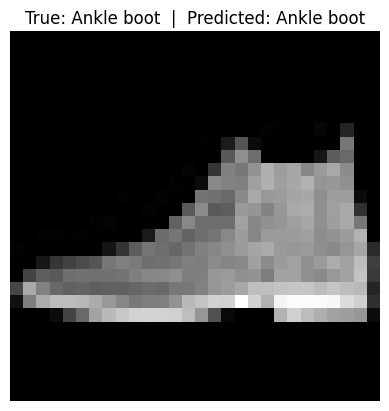

In [9]:
xb, yb = next(iter(test_loader))
x_one  = xb[0].unsqueeze(0).to(device)
y_true = yb[0].item()

pred_class = model(x_one).argmax(1).item()

# Display the image
img_disp = unnormalize(xb[0]).squeeze(0).numpy()
plt.imshow(img_disp, cmap="gray")
plt.title(f"True: {class_names[y_true]}  |  Predicted: {class_names[pred_class]}")
plt.axis("off"); plt.show()